In [2]:
if (!require("pacman")) install.packages("pacman")
pacman::p_load(knitr, tidyverse, ggplot2, dplyr, lubridate, stringr, readxl, data.table, gdata, scales, broom, stargazer, rdrobust)
source("../data-build/functions.R")
source("../data-build/rating_variables.R")

ma_final <- read_csv("../../hwk3/data/output/final-ma-data.csv")

Loading required package: pacman

Rows: 440877 Columns: 110
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (16): contractid, state, county, org_type, plan_type, partd, snp, eghp, ...
dbl (94): planid, fips, n_nonmiss, avg_enrollment, sd_enrollment, min_enroll...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# Question 1

In [3]:
summary_table <- ma_final %>%
    filter(!is.na(Star_Rating)) %>%
  mutate(plan_market_share = avg_enrollment / avg_eligibles) %>%
  group_by(year) %>%
  summarize(
    `Mean Star Rating` = mean(Star_Rating, na.rm = TRUE),
    `Mean Enrollment` = mean(avg_enrollment, na.rm = TRUE),
    `Mean Market Share` = mean(plan_market_share, na.rm = TRUE),
    `Plan Count` = n()
  )%>%
mutate(across(where(is.numeric), ~round(., 3)))

summary_table

year,Mean Star Rating,Mean Enrollment,Mean Market Share,Plan Count
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2010,2.970,345.970,0.012,60519
2011,3.255,388.308,0.015,55249
2012,3.360,410.649,0.017,58169
2013,3.549,406.733,0.016,64174
2014,3.806,451.114,0.018,58636
2015,3.962,482.571,0.019,60819


# Question 2

In [5]:
# Create table for unrated plans
summary_no_stars <- ma_final %>%
 filter(is.na(Star_Rating)) %>%
  mutate(plan_market_share = avg_enrollment / avg_eligibles) %>%
  group_by(year) %>%
  summarize(
    `Mean Enrollment` = mean(avg_enrollment, na.rm = TRUE),
    `Mean Market Share` = mean(plan_market_share, na.rm = TRUE),
    `Count of Plans` = n()
  )%>%
mutate(across(where(is.numeric), ~round(., 3)))

summary_no_stars

year,Mean Enrollment,Mean Market Share,Count of Plans
<dbl>,<dbl>,<dbl>,<dbl>
2010,107.258,0.009,49431
2011,167.899,0.013,12754
2012,172.734,0.012,9077
2013,213.504,0.017,3661
2014,257.596,0.016,3708
2015,314.210,0.009,4680


# Question 3

Warning message:
“Removed 63188 rows containing non-finite values (`stat_count()`).”


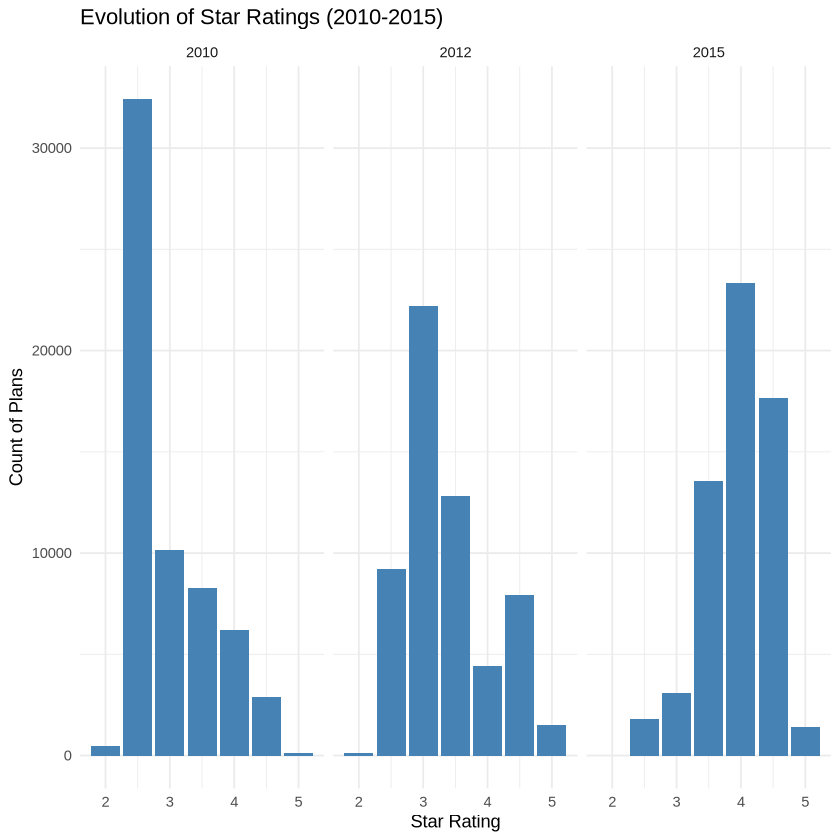

In [9]:
ma_final %>%
  filter(year %in% c(2010, 2012, 2015)) %>%
  ggplot(aes(x = Star_Rating)) +
  geom_bar(fill = "steelblue") +
  facet_wrap(~year, nrow = 1) + 
  labs(
    title = "Evolution of Star Ratings (2010-2015)",
    x = "Star Rating",
    y = "Count of Plans"
  ) +
  theme_minimal()

Between 2010 and 2015, the distribution of MA star ratings saw a large rightward shift (more plans with higher star ratings). In 2010, the market was dominated by lower-rated plans, with 2.5 stars being the most frequent at 30,000+ occurrences. By 2012, the distribution began to center with 3.0 being the most common rating. 2015 shows how the distrubution then shifted to a high-quality skew where 4.0 plans were the highest count of plans, while the count of 2.5 star plans dropped to below 5,000.

# Question 4

In [57]:
# Filter and mutate data
q4.data <- ma_final %>%
  filter(!is.na(Star_Rating)) %>%
  mutate(
    mkt_share = avg_enrollment / avg_enrolled,
    star_cat = case_when(
      Star_Rating <= 2.5 ~ "2.5 or below",
      Star_Rating == 3.0 ~ "3.0",
      Star_Rating == 3.5 ~ "3.5",
      Star_Rating == 4.0 ~ "4.0",
      Star_Rating >= 4.5 ~ "4.5+"
    ),
    star_cat = factor(star_cat, levels = c("2.5 or below", "3.0", "3.5", "4.0", "4.5+"))
  )

# Run regression
models.q4 <- lapply(2010:2015, function(yr) {
  lm(mkt_share ~ star_cat, data = q4.data %>% filter(year == yr))
})

stargazer(models.q4, 
          type = "text", 
          column.labels = as.character(2010:2015),
          dep.var.labels = "Market Share",
          title = "Regression Results: Market Share vs. Star Rating (2010-2015)",
          omit.stat = c("f", "ser"),
        covariate.labels = c("3.0 Stars", "3.5 Stars", "4.0 Stars", "4.5+ Stars", "Constant"))


Regression Results: Market Share vs. Star Rating (2010-2015)
                               Dependent variable:                   
             --------------------------------------------------------
                                   Market Share                      
               2010      2011      2012      2013     2014     2015  
                (1)       (2)       (3)      (4)      (5)      (6)   
---------------------------------------------------------------------
3.0 Stars    0.013***  0.035***  0.031***  0.062*** 0.027*** 0.027***
              (0.002)   (0.002)   (0.003)  (0.003)  (0.006)  (0.005) 
                                                                     
3.5 Stars      0.001   0.019***  0.013***  0.038*** 0.027*** 0.039***
              (0.002)   (0.003)   (0.003)  (0.003)  (0.006)  (0.004) 
                                                                     
4.0 Stars     -0.003     0.003   -0.025*** 0.017***  0.007   0.011***
              (0.002)   (0.0

# Question 5

In [7]:
ma_2010 <- ma_final %>% filter(year == 2010)
rd_table_data <- ma_2010 %>%
  mutate(
    raw_score = rowMeans(
      across(any_of(rating.vars.2010) & where(is.numeric)), 
      na.rm = TRUE
    )
  ) %>%
  filter(!is.na(raw_score)) %>%
  mutate(
    rounded_up = case_when(
      raw_score >= 2.75 & raw_score < 3.00 & Star_Rating == 3.0 ~ "3.0 Stars",
      raw_score >= 3.25 & raw_score < 3.50 & Star_Rating == 3.5 ~ "3.5 Stars",
      raw_score >= 3.75 & raw_score < 4.00 & Star_Rating == 4.0 ~ "4.0 Stars",
      raw_score >= 4.25 & raw_score < 4.50 & Star_Rating == 4.5 ~ "4.5 Stars",
      raw_score >= 4.75 & raw_score < 5.00 & Star_Rating == 5.0 ~ "5.0 Stars",
      TRUE ~ NA_character_
    )
  )

rounding_summary <- rd_table_data %>%
  filter(!is.na(rounded_up)) %>%
  count(rounded_up, name = "Number of Plans Rounded Up") %>%
  rename(`Star Rating` = rounded_up)

rounding_summary

Star Rating,Number of Plans Rounded Up
<chr>,<int>
3.0 Stars,3808
3.5 Stars,4524
4.0 Stars,4077
4.5 Stars,773
5.0 Stars,30


# Question 6

In [8]:
q6_data <- ma_2010 %>%
  mutate(
    raw_score = rowMeans(select(., any_of(rating.vars.2010)) %>% select(where(is.numeric)), na.rm = TRUE),
    mkt_share = avg_enrollment / avg_enrolled
  ) %>%
  filter(!is.na(raw_score), !is.na(mkt_share))

estimate_rd_mkt_share <- function(data, threshold, bw = 0.125) {
  data %>%
    mutate(dist = raw_score - threshold) %>%
    filter(abs(dist) <= bw) %>%
    mutate(treated = ifelse(dist >= 0, 1, 0)) %>%
 
    lm(mkt_share ~ treated + dist + I(treated * dist), data = .)
}

# Run models
model_30_share <- estimate_rd_mkt_share(q6_data, 2.75)
model_35_share <- estimate_rd_mkt_share(q6_data, 3.25)

# Make pretty table
stargazer(model_30_share, model_35_share, 
          type = "text", 
          column.labels = c("3.0 Stars", "3.5 Stars"),
          dep.var.labels = "Market Share",
          covariate.labels = c("Rounded", "Running Score", "Rounded x Score"),
          omit.stat = c("f", "ser"),
          title = "Table 6: RD Estimates of Star Rating on Market Share")


Table 6: RD Estimates of Star Rating on Market Share
                    Dependent variable:     
                ----------------------------
                        Market Share        
                  3.0 Stars      3.5 Stars  
                     (1)            (2)     
--------------------------------------------
Rounded            0.046***      -0.049***  
                   (0.007)        (0.009)   
                                            
Running Score     -0.589***      0.522***   
                   (0.039)        (0.070)   
                                            
Rounded x Score    0.656***      -0.552***  
                   (0.093)        (0.097)   
                                            
Constant           0.022***      0.110***   
                   (0.003)        (0.007)   
                                            
--------------------------------------------
Observations        5,984          2,172    
R2                  0.038          0.026    
A

# Question 7

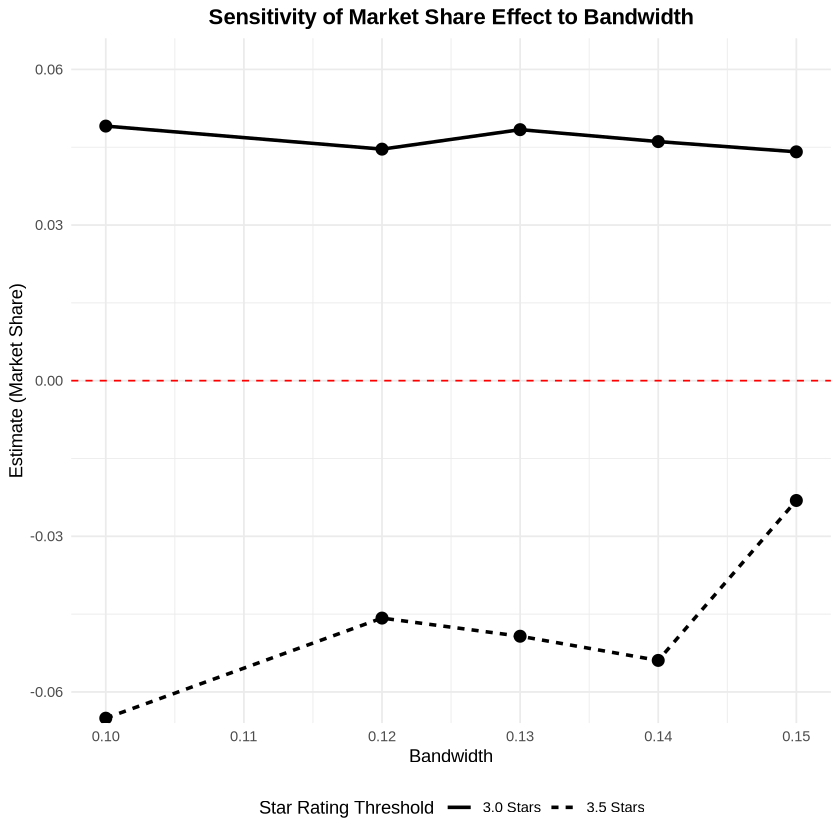

In [11]:
bandwidths <- c(0.1, 0.11, 0.12, 0.13, 0.14, 0.15)
ggplot(sensitivity_results, aes(x = bandwidth, y = estimate, group = threshold, linetype = threshold)) +
  geom_line(color = "black", linewidth = 1) +
  geom_point(color = "black", size = 3) +
  
  scale_x_continuous(breaks = bandwidths) +
  
# Set y-axis so results aren't cut off
  coord_cartesian(ylim = c(-0.06, 0.06)) + 
  
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  
  theme_minimal() +
  labs(
    title = "Sensitivity of Market Share Effect to Bandwidth",
    x = "Bandwidth",
    y = "Estimate (Market Share)",
    linetype = "Star Rating Threshold"
  ) +
  theme(
    legend.position = "bottom",
    plot.title = element_text(hjust = 0.5, face = "bold")
  )

This bandwidth sensitivity analysis shows that RD estimates are robust to the choice of bandwidth. Regardless of window size (0.1 to 0.15), the estimated effect of a star rating increase remains statistically insignificant.

# Question 8

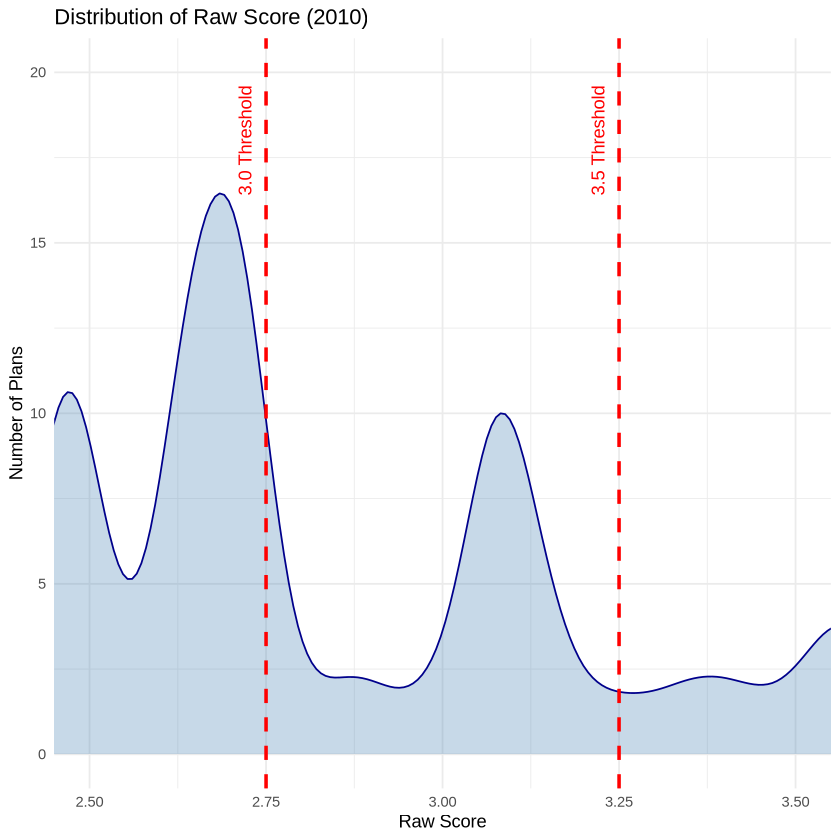

In [19]:
# Define thresholds
thresholds <- c(2.75, 3.25)

ggplot(rd_table_data, aes(x = raw_score)) +
 # Scale y axis
  geom_density(aes(y = ..density.. * 10), fill = "steelblue", alpha = 0.3, color = "darkblue", adjust = 1) +
  
  # Add threshold lines
  geom_vline(xintercept = thresholds, linetype = "dashed", color = "red", linewidth = 1) +
  
  # Text adjusted for axes
  annotate("text", x = 2.72, y = 18, label = "3.0 Threshold", angle = 90, color = "red") +
  annotate("text", x = 3.22, y = 18, label = "3.5 Threshold", angle = 90, color = "red") +
  
  coord_cartesian(xlim = c(2.5, 3.5), ylim = c(0, 20)) +
  
  theme_minimal() +
  labs(
    title = "Distribution of Raw Score (2010)",
    x = "Raw Score",
    y = "Number of Plans"
  )

The density plot shows a continuous distribution across the 2.75 and 3.25 thresholds (at which scores are rounded up to 3 and 3.5, respectively). There is no bunching or a discontinuous jump in the density of plans immediately following the rounding cutoffs. This supports the earlier findings that contracts did not strategically manipulate quality metrics to cross the thresholds in 2010.

# Question 9

In [48]:
q9_data <- ma_2010 %>% 
  mutate(
    raw_score = rowMeans(select(., any_of(rating.vars.2010)) %>% select(where(is.numeric)), na.rm = TRUE),
    mkt_share = avg_enrollment / avg_enrolled,
    
    # HMO status
    is_hmo = ifelse(str_detect(org_type, "HMO") | str_detect(plan_type, "HMO"), 1, 0),
    
    # Part D status
    has_partd = ifelse(partd == "Yes", 1, 0)
  ) %>% 
  filter(!is.na(raw_score), !is.na(mkt_share))


# Run balance regression and return model
get_balance_model <- function(data, threshold, covariate) {
  data %>%
    filter(abs(raw_score - threshold) <= 0.125) %>%
    mutate(dist = raw_score - threshold,
           treated = ifelse(dist >= 0, 1, 0)) %>%
    lm(as.formula(paste(covariate, "~ treated + dist")), data = .)
}

# 3.0 stars
hmo_30_mod   <- get_balance_model(q9_data, 2.75, "is_hmo")
partd_30_mod <- get_balance_model(q9_data, 2.75, "has_partd")

# 3.5 stars
hmo_35_mod   <- get_balance_model(q9_data, 3.25, "is_hmo")
partd_35_mod <- get_balance_model(q9_data, 3.25, "has_partd")

# Generate t stat table
stargazer(hmo_30_mod, partd_30_mod, hmo_35_mod, partd_35_mod, 
          type = "text", 
          column.labels = c("HMO (3.0)", "Part D (3.0)", "HMO (3.5)", "Part D (3.5)"),
          dep.var.labels.include = FALSE, 
          keep = "treated",               
          covariate.labels = "Mean Difference",
          title = "Table 1: Covariate Balance (2010)",
          omit.stat = c("f", "ser", "adj.rsq", "rsq"), 
          report = "vct*",     
          notes = "Bandwidth = 0.125")


Table 1: Covariate Balance (2010)
                                  Dependent variable:                  
                -------------------------------------------------------
                  HMO (3.0)   Part D (3.0)    HMO (3.5)    Part D (3.5)
                     (1)           (2)           (3)           (4)     
-----------------------------------------------------------------------
Mean Difference     0.307         0.491         -0.609        -0.058   
                t = 19.481*** t = 15.598*** t = -13.797*** t = -1.751* 
                                                                       
-----------------------------------------------------------------------
Observations        5,984         5,984         2,172         2,172    
Note:                                       *p<0.1; **p<0.05; ***p<0.01
                                                      Bandwidth = 0.125


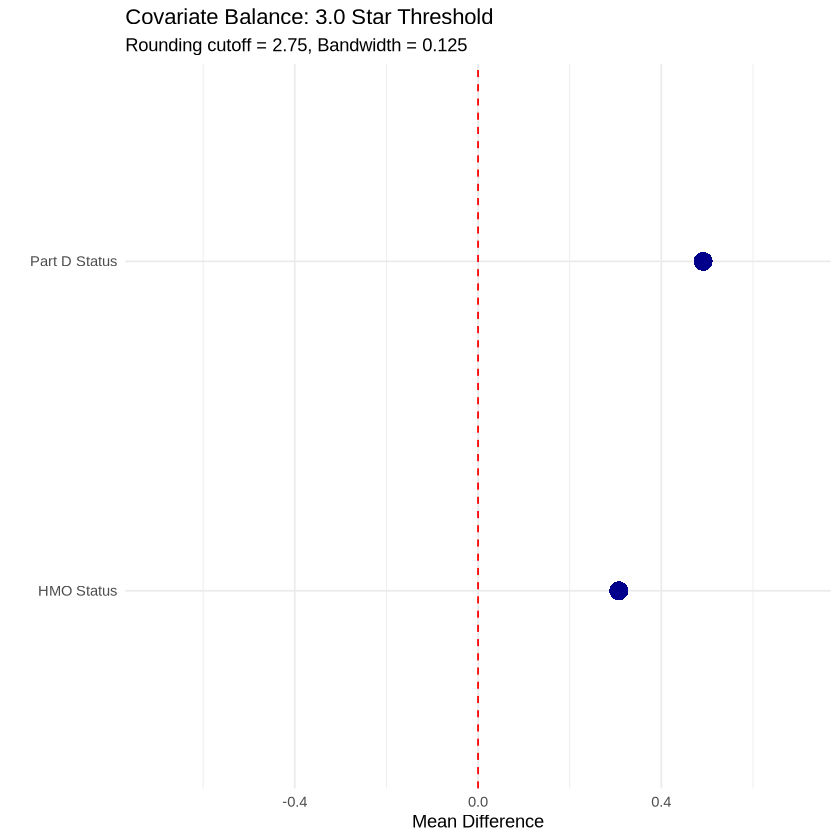

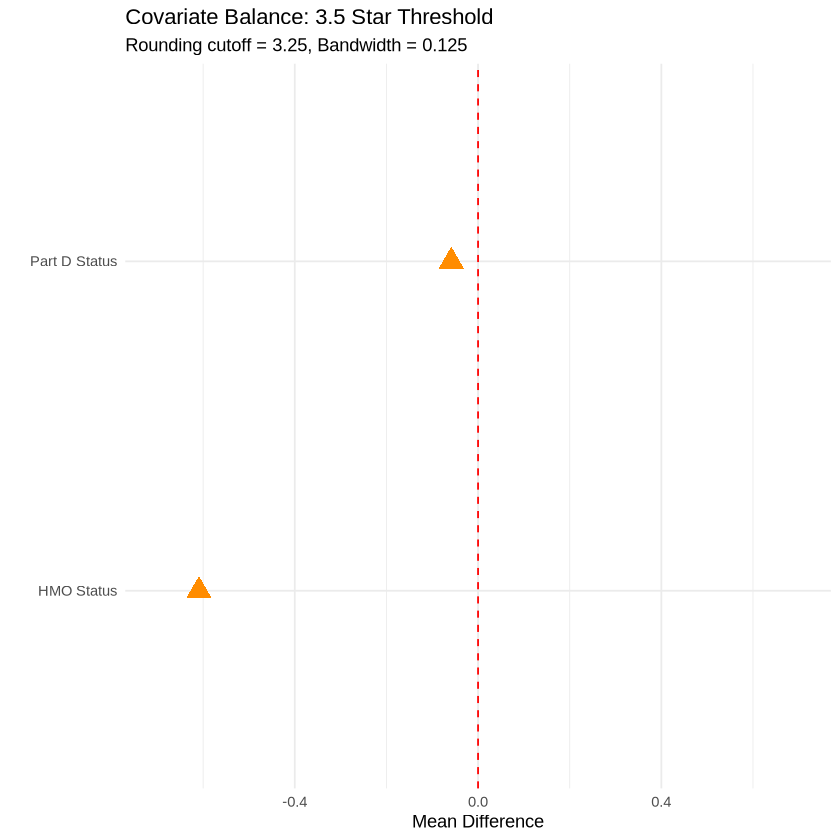

In [54]:
# Love plot for 3.0 star threshold
plot_30 <- love_plot_df %>%
  filter(Threshold == "3.0 Stars") %>%
  ggplot(aes(x = Mean_Diff, y = Covariate)) +
  geom_point(size = 5, color = "darkblue", shape = 16) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "red") +
  theme_minimal() +
  labs(
    title = "Covariate Balance: 3.0 Star Threshold",
    subtitle = "Rounding cutoff = 2.75, Bandwidth = 0.125",
    x = "Mean Difference",
    y = ""
  ) +
  coord_cartesian(xlim = c(-0.7, 0.7))

# Love plot for 3.5 star
plot_35 <- love_plot_df %>%
  filter(Threshold == "3.5 Stars") %>%
  ggplot(aes(x = Mean_Diff, y = Covariate)) +
  geom_point(size = 5, color = "darkorange", shape = 17) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "red") +
  theme_minimal() +
  labs(
    title = "Covariate Balance: 3.5 Star Threshold",
    subtitle = "Rounding cutoff = 3.25, Bandwidth = 0.125",
    x = "Mean Difference",
    y = ""
  ) +
  coord_cartesian(xlim = c(-0.7, 0.7))

plot_30
plot_35

# Question 10

Overall conclusion: Looking at results from questions 5-9, we can conclude that increasing star rating had no statistically significant effect on MA enrollments in 2010.

Questions 6/7: RD estimates at the 3.0 and 3.5-star thresholds were statistically insignificant across all tested bandwidths (0.1 to 0.15). This demonstrates that jumping to a higher star rating did not cause a discontinuous boost in enrollment.

Question 9: The T-statistic table reveals large imbalance. Plans just above 2.75 were 30.7% more likely to be HMOs ($t = 19.481$) and 49.1% more likely to offer Part D ($t = 15.598$). Both HMO status and Part D status show statistically significant discontinuities at the 2.75 and 3.25 thresholds. This indicates that plans above the rounding cutoffs were systematically different from those just below. Therefore, any observed effect on enrollment cannot be attributed only to the star rating, since these underlying plan characteristics likely confound the estimate.